# 02｜端到端機器學習專案

對應 `slides/02_端到端機器學習專案.md`。原分冊依教學順序合併，各節仍可獨立選講。

## 資料探索與切分

原始分冊：`03_房價資料探索與切分.ipynb`。內容與已執行輸出完整併入本課同名 Notebook。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

## 1. 問題定義與資料字典

以地理區域的 8 個數值特徵與 `ocean_proximity` 類別特徵預測 `median_house_value`（美元）。一列是一個區域，不能解讀成單一房屋價格。資料是歷史快照，房價存在封頂；不能直接用於今日估價。

主指標 RMSE：較強懲罰大誤差；輔助 MAE：提供另一種誤差尺度。假設部署的取樣單位／年代與開發資料一致；若預測新地區或未來年代，應再設地區／時間驗證。

In [2]:
from mlcourse.common import housing_split
from sklearn.model_selection import train_test_split
train,test=housing_split()
assert len(train)==16512 and len(test)==4128
print('Training rows:',len(train),'Locked test rows:',len(test))
print('Input columns:',len(train.columns)-1)
train.head()

Training rows: 16512 Locked test rows: 4128
Input columns: 9


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN


In [3]:
summary=pd.DataFrame({'dtype':train.dtypes.astype(str),'missing_train':train.isna().sum(),
                      'unique_train':train.nunique()})
summary

,dtype,missing_train,unique_train
longitude,float64,0,817
latitude,float64,0,835
housing_median_age,float64,0,52
total_rooms,float64,0,5473
total_bedrooms,float64,168,1827
population,float64,0,3640
households,float64,0,1712
median_income,float64,0,10930
median_house_value,float64,0,3674
ocean_proximity,object,0,5


## 2. 依收入階層分層
下表只比較收入特徵的比例；取樣時可依事先指定的特徵分層。收入階層只用於取樣，不加入模型。不同 seed 的單次隨機切分可能碰巧很好；不能由一次結果宣稱分層永遠改善預測。

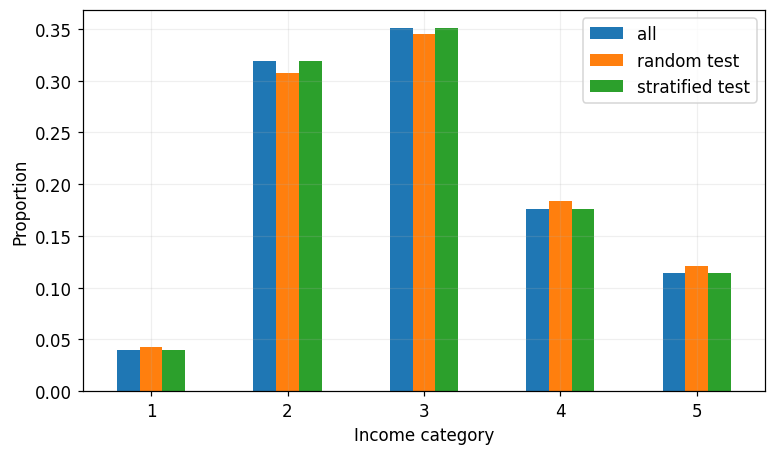

,all,random test,stratified test,random_error_pct,stratified_error_pct
median_income,,,,,
1,0.039826,0.042393,0.039971,6.447689,0.364964
2,0.318847,0.307413,0.318798,-3.586081,-0.015195
3,0.350581,0.345203,0.350533,-1.533997,-0.013820
4,0.176308,0.184109,0.176357,4.424292,0.027480
5,0.114438,0.120882,0.114341,5.630821,-0.084674


In [4]:
frame=pd.concat([train,test]).sort_index()
def income_cat(df):
    return pd.cut(df.median_income,[0,1.5,3,4.5,6,np.inf],labels=[1,2,3,4,5])
random_train,random_test=train_test_split(frame,test_size=.2,random_state=SEED)
proportions=pd.DataFrame({name:income_cat(df).value_counts(normalize=True).sort_index()
    for name,df in [('all',frame),('random test',random_test),('stratified test',test)]})
proportions.plot.bar();plt.ylabel('Proportion');plt.xlabel('Income category');plt.xticks(rotation=0)
savefig('03_stratified_sampling')
proportions.assign(random_error_pct=100*(proportions['random test']/proportions['all']-1),
                   stratified_error_pct=100*(proportions['stratified test']/proportions['all']-1))

## 3. 只對 training data 做 EDA

位置、收入與房價的共同變化能提出假設，不能識別因果。此處無外部底圖；散點經緯度直接來自資料。

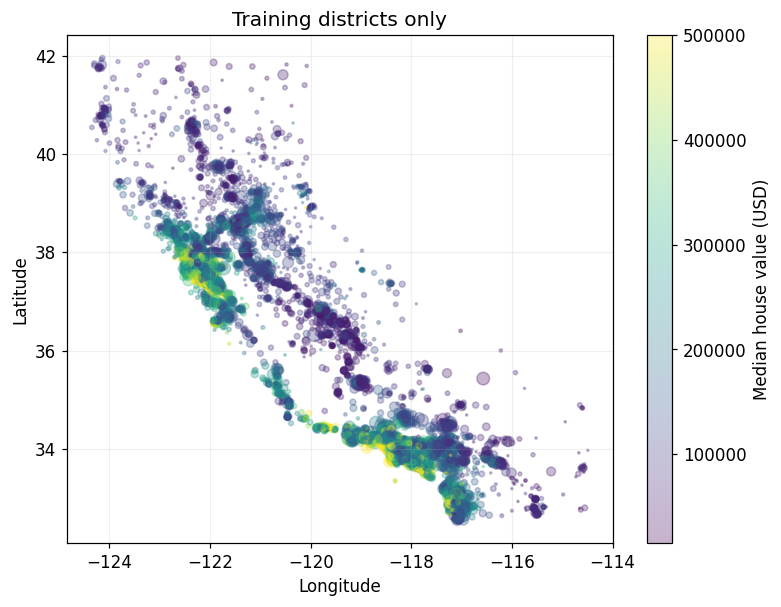

In [5]:
fig,ax=plt.subplots(figsize=(8,6))
points=ax.scatter(train.longitude,train.latitude,s=np.clip(train.population/100,2,80),
                  c=train.median_house_value,cmap='viridis',alpha=.3)
fig.colorbar(points,ax=ax,label='Median house value (USD)')
ax.set(xlabel='Longitude',ylabel='Latitude',title='Training districts only')
savefig('03_housing_geography')

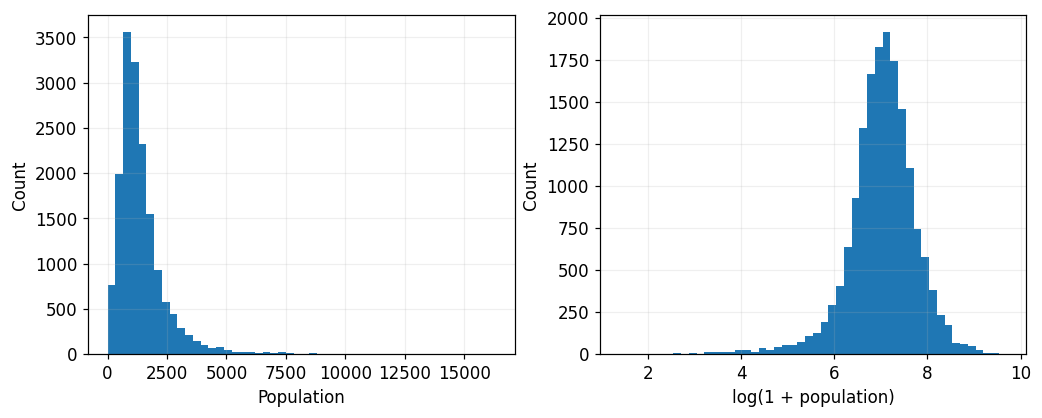

Training targets at/above 500001: 764


In [6]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].hist(train.population,bins=50);axes[0].set(xlabel='Population',ylabel='Count')
axes[1].hist(np.log1p(train.population),bins=50);axes[1].set(xlabel='log(1 + population)',ylabel='Count')
savefig('03_long_tail')
print('Training targets at/above 500001:',int((train.median_house_value>=500001).sum()))

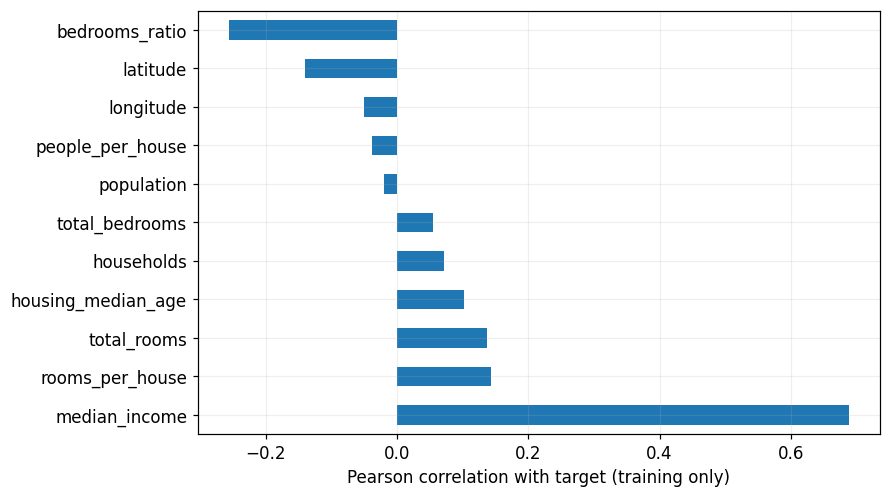

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

In [7]:
eda=train.copy()
eda['rooms_per_house']=eda.total_rooms/eda.households
eda['bedrooms_ratio']=eda.total_bedrooms/eda.total_rooms
eda['people_per_house']=eda.population/eda.households
corr=eda.select_dtypes('number').corr()['median_house_value'].sort_values(ascending=False)
corr.drop('median_house_value').plot.barh(figsize=(8,5))
plt.xlabel('Pearson correlation with target (training only)');savefig('03_feature_correlations')
corr

**注意：** 這裡加入特徵是為了探索；正式模型會把相同計算放回 Pipeline。Pearson 相關低不代表沒有非線性關係。房價封頂影響誤差解讀；不要在觀察 test 後自行刪掉難預測的樣本。

## 4. 選做：固定 seed 為何還不夠？

此為自編穩定 ID 示意。使用 SHA-256 的前 64 位元作決定，不用 Python `hash()`（可能因程序而改變）。ID 必須永久且唯一；以下 `district-0001` 為合成 ID，不宣稱房價資料已有業務 ID。哈希比例是期望值，不保證恰好 20%，也不保證分層或群組隔離。

In [8]:
import hashlib
def in_test(identifier,ratio=.2):
    value=int.from_bytes(hashlib.sha256(str(identifier).encode()).digest()[:8],'big')
    return value < ratio*2**64
ids=pd.Series([f'district-{i:04d}' for i in range(1000)])
original=set(ids[ids.map(in_test)])
reordered=ids.sample(frac=1,random_state=SEED)
extended=pd.concat([reordered,pd.Series(['district-new-1','district-new-2'])],ignore_index=True)
new_members=set(extended[extended.map(in_test)])
assert original == new_members.intersection(set(ids))
_,r1=train_test_split(ids.to_numpy(),test_size=.2,random_state=SEED)
_,r2=train_test_split(reordered.to_numpy(),test_size=.2,random_state=SEED)
print('Hash test members:',len(original),'same after reorder + append:',True)
print('Random split members changed by reordering:',len(set(r1)^set(r2)))
report('housing_split',{'train_rows':len(train),'test_rows':len(test),'overlap':len(set(train.index)&set(test.index)),
                        'hash_stable':True,'hash_test_rows':len(original)})

Hash test members: 216 same after reorder + append: True
Random split members changed by reordering: 334


## 練習

1. 哪些欄位的缺失需要填補？**`total_bedrooms`；以實際表格為準。**
2. 取樣用收入分層，是否已解決未來房價漂移？**沒有，時間／地區代表性仍需另外檢查。**
3. 若地理鄰近區域高度相似，隨機 CV 能代表新城市嗎？**未必；可用地理群組驗證，見 08 的群組與時間示例。**

下一本從相同固定切分重新開始，可單獨執行。

## Pipeline、模型選擇與最後測試

原始分冊：`04_房價Pipeline與模型選擇.ipynb`。內容與已執行輸出完整併入本課同名 Notebook。

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

In [10]:
from mlcourse.common import housing_split
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.base import clone
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
train,locked_test=housing_split()
if FAST:
    cats=pd.cut(train.median_income,[0,1.5,3,4.5,6,np.inf],labels=[1,2,3,4,5])
    train,_=train_test_split(train,train_size=6000,random_state=SEED,stratify=cats)
X_train=train.drop(columns='median_house_value');y_train=train.median_house_value
print('Model development rows:',len(train),'locked test:',len(locked_test))
folds=list(KFold(3,shuffle=True,random_state=SEED).split(X_train))

Model development rows: 6000 locked test: 4128


## 1. 自訂轉換器的介面

`__init__` 只保留超參數，`fit` 回傳 self 並記錄欄數，`transform` 使用已 fit 的狀態。類別放在可匯入的 `mlcourse.transformers`，讓模型可在另一個 Python 程序載入。下格顯示完整實作，核心邏輯不需猜測。

分母為 0 時回傳 0 是本課程明示的示範政策；正式應依領域決定拒收、缺失標記或其他處理。比率前的填補器仍必須在每個訓練 fold 裡 fit。

In [11]:
import inspect
from mlcourse.transformers import RatioTransformer
print(inspect.getsource(RatioTransformer))
assert np.array_equal(RatioTransformer().fit_transform([[6,3],[4,0]]),[[2],[0]])

class RatioTransformer(TransformerMixin, BaseEstimator):
    """Two numeric columns -> numerator / denominator; zero yields 0."""
    def fit(self, X, y=None):
        X = check_array(X)
        if X.shape[1] != 2:
            raise ValueError('RatioTransformer requires exactly two columns')
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        check_is_fitted(self, 'n_features_in_')
        X = check_array(X)
        if X.shape[1] != self.n_features_in_:
            raise ValueError('Feature count differs from fit')
        return np.divide(X[:, [0]], X[:, [1]],
                         out=np.zeros((len(X), 1)), where=X[:, [1]] != 0)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, 'n_features_in_')
        return np.array(['ratio'], dtype=object)



## 2. 組合 ColumnTransformer → Pipeline
人口／房間等非負長尾欄先填補再 log1p；經緯度等欄保留原尺度結構後標準化；ocean proximity 無自然次序，使用 one-hot。遇到新類別時忽略該類別編碼，不代表模型理解新類別。

In [12]:
ordinary=['longitude','latitude','housing_median_age','median_income']
long_tail=['total_rooms','total_bedrooms','population','households']
def ratio_pipe():
    return make_pipeline(SimpleImputer(strategy='median'),RatioTransformer(),StandardScaler())
preprocess=ColumnTransformer([
    ('num',make_pipeline(SimpleImputer(strategy='median'),StandardScaler()),ordinary),
    ('log',make_pipeline(SimpleImputer(strategy='median'),
                        FunctionTransformer(np.log1p,feature_names_out='one-to-one'),StandardScaler()),long_tail),
    ('rooms_per_house',ratio_pipe(),['total_rooms','households']),
    ('bedrooms_ratio',ratio_pipe(),['total_bedrooms','total_rooms']),
    ('people_per_house',ratio_pipe(),['population','households']),
    ('cat',make_pipeline(SimpleImputer(strategy='most_frequent'),
                        OneHotEncoder(handle_unknown='ignore',sparse_output=False)),['ocean_proximity'])
])
# 這個 preview 只供看欄位；CV 下方另 clone 整條管線，沒有使用 preview 的已轉換陣列。
preview=clone(preprocess).fit(X_train)
prepared=preview.transform(X_train.iloc[:5])
assert np.isfinite(prepared).all()
pd.DataFrame(prepared,columns=preview.get_feature_names_out())

,num__longitude,num__latitude,num__housing_median_age,num__median_income,log__total_rooms,log__total_bedrooms,log__population,log__households,rooms_per_house__ratio,bedrooms_ratio__ratio,people_per_house__ratio,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN
0,-0.480576,0.965306,-0.862757,-1.389330,-2.463016,-2.392763,-2.443981,-2.446689,-0.161911,0.166423,-0.113059,0.0,1.0,0.0,0.0,0.0
1,-1.141434,0.955923,0.824198,-0.726345,-1.862258,-1.808674,-2.663277,-1.871508,-0.118127,0.103900,-1.307579,0.0,1.0,0.0,0.0,0.0
2,0.607605,-0.784607,1.065191,-0.516468,-0.199319,0.014999,0.405437,-0.059516,-0.280413,0.373854,0.987656,1.0,0.0,0.0,0.0,0.0
3,0.711951,-0.859670,1.225853,-0.368408,0.200211,0.519406,0.362825,0.553307,-0.521494,0.601974,-0.452428,0.0,0.0,0.0,0.0,1.0
4,-1.404784,0.988763,1.707840,-0.207796,-0.076865,-0.051179,0.057531,-0.045049,-0.135743,-0.045941,0.104200,0.0,0.0,0.0,1.0,0.0


## 3. 基準與 CV
先加入「永遠預測開發集房價均值」的常數基準；任何模型至少要明顯優於它，否則等於沒學到區域差異。相同三折比較常數基準、線性模型、決策樹及森林。訓練分數是各折訓練資料的平均，不是完整資料重訓的分數；兩者不可混用。折間標準差不是正式信賴區間。

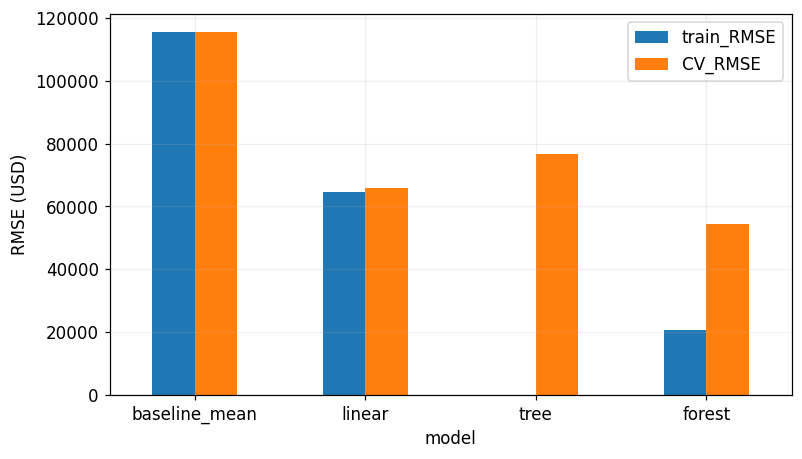

,train_RMSE,CV_RMSE,CV_SD
model,,,
baseline_mean,115525.796888,115525.755548,849.129681
linear,64734.965593,65893.615225,2685.970832
tree,-0.000000,76750.154213,2060.216190
forest,20813.012048,54493.380066,3063.286739


In [13]:
# 主指標 RMSE 用均值基準；若改以 MAE 為主，對應基準是 strategy='median'。
models={'baseline_mean':DummyRegressor(strategy='mean'),
        'linear':LinearRegression(),
        'tree':DecisionTreeRegressor(random_state=SEED),
        'forest':RandomForestRegressor(n_estimators=40,max_features=.8,n_jobs=2,random_state=SEED)}
rows=[]
for name,est in models.items():
    pipe=Pipeline([('preprocess',clone(preprocess)),('model',est)])
    scores=cross_validate(pipe,X_train,y_train,cv=folds,scoring='neg_root_mean_squared_error',return_train_score=True)
    rows.append({'model':name,'train_RMSE':-scores['train_score'].mean(),
                 'CV_RMSE':-scores['test_score'].mean(),'CV_SD':scores['test_score'].std(ddof=1)})
baselines=pd.DataFrame(rows).set_index('model')
baselines[['train_RMSE','CV_RMSE']].plot.bar();plt.ylabel('RMSE (USD)');plt.xticks(rotation=0)
savefig('04_train_vs_cv')
baselines

## 4. 網格與隨機搜尋

事先限定森林家族示範兩種搜尋；各用 4 個候選、3 folds。以較高的平均負 RMSE 選出最終候選。重用同一 folds 做選擇，最佳 CV 數字會帶選擇偏差，因此仍保留最終 test。

`preprocess__...`／`model__...` 是管線超參數路徑。這裡固定特徵工程，僅搜尋森林；可選擴充時先估算 `候選數 × folds` 的運算成本。

In [14]:
from scipy.stats import randint
forest_pipe=Pipeline([('preprocess',clone(preprocess)),('model',clone(models['forest']))])
grid=GridSearchCV(forest_pipe,{'model__max_features':[.6,1.0],'model__min_samples_leaf':[1,4]},
                  cv=folds,scoring='neg_root_mean_squared_error',n_jobs=1)
random=RandomizedSearchCV(forest_pipe,{'model__max_features':[.5,.7,1.0],
                    'model__min_samples_leaf':randint(1,9)},n_iter=4,cv=folds,
                    scoring='neg_root_mean_squared_error',random_state=SEED,n_jobs=1)
for search in [grid,random]:
    search.fit(X_train,y_train)
searches={'grid':grid,'random':random}
search_rows=[{'search':name,'best_CV_RMSE':-s.best_score_,'params':s.best_params_} for name,s in searches.items()]
chosen_search=max(searches,key=lambda name:searches[name].best_score_)
final_model=searches[chosen_search].best_estimator_
print('Chosen by CV:',chosen_search)
pd.DataFrame(search_rows)

Chosen by CV: grid


,search,best_CV_RMSE,params
0,grid,53831.244378,"{'model__max_features': 0.6, 'model__min_sampl..."
1,random,54126.830136,"{'model__max_features': 0.5, 'model__min_sampl..."


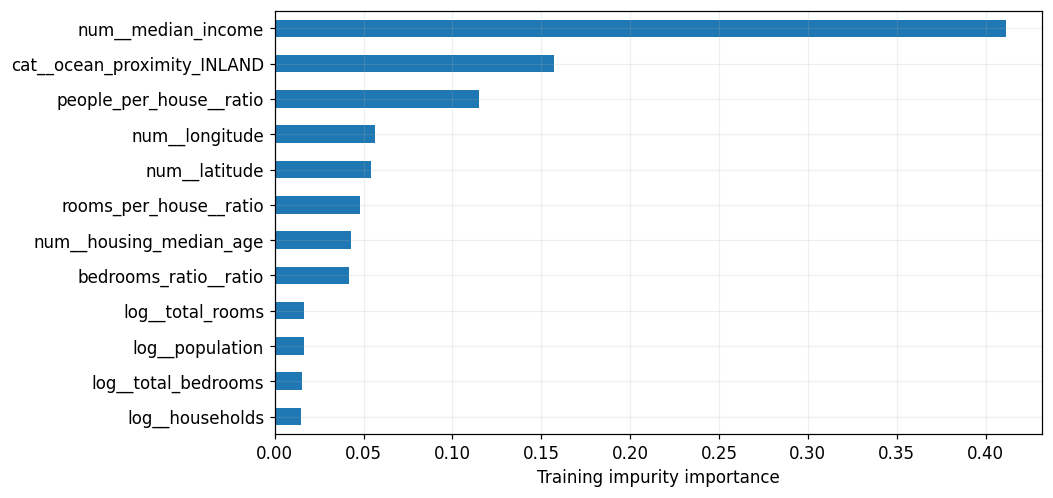

In [15]:
importance=pd.Series(final_model['model'].feature_importances_,
                     index=final_model['preprocess'].get_feature_names_out()).sort_values()
importance.tail(12).plot.barh(figsize=(9,5));plt.xlabel('Training impurity importance')
savefig('04_feature_importance')
# 模擬缺失值及未見類別，只測試 API 能否處理，並非部署效能證明。
probe=X_train.iloc[:2].copy();probe.loc[probe.index[0],'total_bedrooms']=np.nan
probe.loc[probe.index[1],'ocean_proximity']='UNSEEN_CATEGORY'
assert np.isfinite(final_model.predict(probe)).all()

重要度來自森林的訓練分裂，可偏好高基數特徵；相關／重複特徵會分攤重要度。不可解讀成因果貢獻。若想據此刪特徵，必須回到開發集 CV，不能用下一段 test 成效決定刪留。

## 5. 最終測試與 RMSE 信賴區間

先固定模型，再開啟 4,128 筆 test。Bootstrap 重抽已固定模型的逐筆平方誤差，以估計 i.i.d. 測試區域下 RMSE 的抽樣不確定性；不包含重新訓練、搜尋、地理相依或未來漂移的不確定性。95% CI 不是 95% 房價預測區間，也不是模型比較的假設檢定。

In [16]:
from scipy.stats import bootstrap
X_test=locked_test.drop(columns='median_house_value');y_test=locked_test.median_house_value
prediction=final_model.predict(X_test)
squared=(prediction-y_test.to_numpy())**2
def rmse_stat(errors,axis=-1):
    return np.sqrt(np.mean(errors,axis=axis))
ci=bootstrap((squared,),rmse_stat,n_resamples=1500,batch=100,method='percentile',random_state=SEED).confidence_interval
metrics={'profile':'fast' if FAST else 'full','train_rows':len(train),'test_rows':len(y_test),
         'chosen_search':chosen_search,'best_params':searches[chosen_search].best_params_,
         'test_RMSE':root_mean_squared_error(y_test,prediction),'test_MAE':mean_absolute_error(y_test,prediction),
         'test_R2':r2_score(y_test,prediction),
         'RMSE_CI_95':[float(ci.low),float(ci.high)]}
report('housing_final',metrics)
pd.Series(metrics)

profile                                                       fast
train_rows                                                    6000
test_rows                                                     4128
chosen_search                                                 grid
best_params      {'model__max_features': 0.6, 'model__min_sampl...
test_RMSE                                             53174.846597
test_MAE                                              35352.762385
test_R2                                                   0.788766
RMSE_CI_95                 [50976.833838637045, 55673.41547333377]
dtype: object

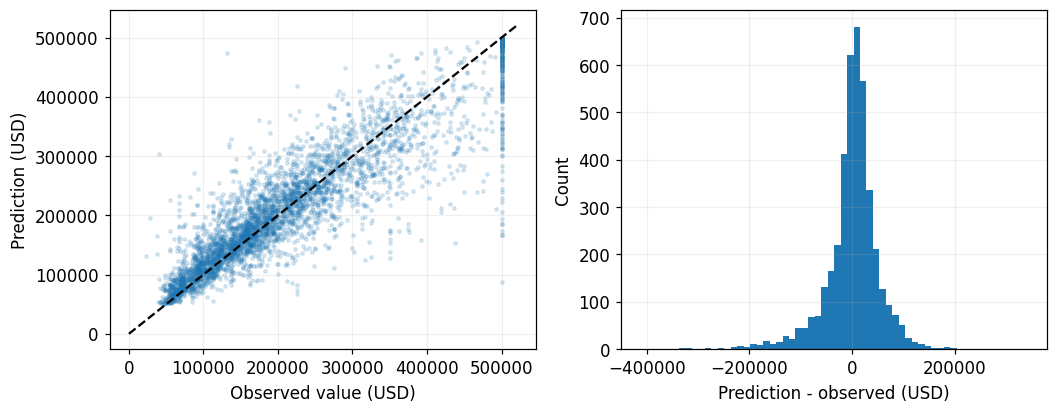

In [17]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].scatter(y_test,prediction,s=5,alpha=.15);axes[0].plot([0,520000],[0,520000],'k--')
axes[0].set(xlabel='Observed value (USD)',ylabel='Prediction (USD)')
axes[1].hist(prediction-y_test,bins=60);axes[1].set(xlabel='Prediction - observed (USD)',ylabel='Count')
savefig('04_final_residuals')

## 6. 儲存整條管線並驗證可載入
保存前處理與模型，推論接收原始欄位。只載入自己信任來源的 joblib；它會反序列化 Python 物件。本次是本機推論示範，尚未建置外部服務。

In [18]:
import joblib, json, sklearn
model_dir=OUT/'models';model_dir.mkdir(exist_ok=True)
model_file=model_dir/'housing_pipeline.joblib'
joblib.dump(final_model,model_file)
loaded=joblib.load(model_file)
assert np.allclose(loaded.predict(X_test.iloc[:10]),prediction[:10])
metadata={'sklearn':sklearn.__version__,'raw_features':list(X_train.columns),
          'data_sha256':json.loads((DATA/'manifest.json').read_text())['housing.csv']['sha256'],
          'metrics':metrics}
(model_dir/'housing_metadata.json').write_text(json.dumps(metadata,ensure_ascii=False,indent=2))
print('Saved:',model_file.name)
print('Reload equality: PASS')

Saved: housing_pipeline.joblib
Reload equality: PASS


## 練習與討論

1. 把 scaler 放在 CV 外面會出什麼問題？**每折驗證分布已參與轉換參數的估計。**
2. `GridSearchCV` 的 `best_estimator_` 已重訓在哪裡？**提供給 fit 的完整開發資料；fast 模式為 6,000 筆。**
3. 要用完整 16,512 筆重跑，可先設定 full 模式，再啟動核心；必須重新記錄結果，不能混用 fast 的表格。
4. 若 test 比 CV 差，不能立刻反覆調參迎合 test；先研究資料來源／分布，並安排新的獨立評估。